# Clase 10 — APIs, datos abiertos y proyecto final

**Python y Políticas Públicas**

---

## Contenidos
1. ¿Qué es una API REST?
2. Consumir APIs con `requests`
3. API de datos.gob.ar
4. API del Banco Mundial
5. Estructura del proyecto final: el policy brief con datos
6. Checklist de entrega
7. Taller: presentación de avances

---
## 1. ¿Qué es una API REST?

Una **API** (Application Programming Interface) es una interfaz que permite que dos programas se comuniquen. Una **API REST** usa el protocolo HTTP y devuelve datos generalmente en formato JSON.

**¿Por qué es importante para políticas públicas?**

En lugar de descargar manualmente archivos de un portal, podemos:
- Acceder a datos actualizados automáticamente
- Filtrar y pedir solo los datos que necesitamos
- Combinar datos de múltiples fuentes en un script

**Cómo funciona una request HTTP básica:**

```
Mi script                     Servidor de datos
    │                               │
    │── GET /api/datos?año=2023 ──►  │
    │                               │
    │◄── JSON con los datos ────────│
```

**Códigos de respuesta HTTP:**
- `200 OK`: todo bien, datos recibidos
- `404 Not Found`: el endpoint no existe
- `429 Too Many Requests`: excediste el límite de requests
- `500 Internal Server Error`: error del servidor

---
## 2. Consumir APIs con `requests`

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

%matplotlib inline
pd.set_option('display.max_columns', None)

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- Paleta de identidad del curso ---
C = ['#2A6496', '#E07B3F', '#3D9970', '#8E5EA2', '#C0A830', '#637A8A']

mpl.rcParams.update({
    'figure.figsize'       : (10, 5),
    'font.size'            : 11,
    'axes.titlesize'       : 12,
    'axes.titleweight'     : 'normal',
    'axes.spines.top'      : False,
    'axes.spines.right'    : False,
    'legend.frameon'       : False,
    'axes.prop_cycle'      : mpl.cycler(color=C),
    'figure.dpi'           : 110,
})

def tit(ax, t, **kw):
    """Título sin negrita, alineado a la izquierda."""
    ax.set_title(t, loc='left', fontweight='normal', **kw)


In [3]:
# Ejemplo básico: consultar una API pública
# Usamos la API de tipo de cambio del BCRA (Banco Central)

def get_api(url, params=None, timeout=10):
    """Wrapper seguro para requests con manejo de errores."""
    try:
        resp = requests.get(url, params=params, timeout=timeout)
        resp.raise_for_status()  # lanza excepción si status != 200
        return resp.json()
    except requests.exceptions.Timeout:
        print("Error: la request tardó demasiado")
    except requests.exceptions.HTTPError as e:
        print(f"Error HTTP: {e}")
    except requests.exceptions.ConnectionError:
        print("Error: sin conexión a internet")
    except json.JSONDecodeError:
        print("Error: la respuesta no es JSON válido")
    return None

# Test: API pública de ejemplo
datos = get_api("https://jsonplaceholder.typicode.com/posts/1")
if datos:
    print(json.dumps(datos, indent=2))

{
  "userId": 1,
  "id": 1,
  "title": "sunt aut facere repellat provident occaecati excepturi optio reprehenderit",
  "body": "quia et suscipit\nsuscipit recusandae consequuntur expedita et cum\nreprehenderit molestiae ut ut quas totam\nnostrum rerum est autem sunt rem eveniet architecto"
}


---
## 3. API de datos.gob.ar

El portal de datos abiertos del gobierno argentino (datos.gob.ar) expone una API basada en CKAN (el mismo estándar que usan muchos portales de datos del mundo).

In [4]:
# API de datos.gob.ar: buscar datasets
BASE_URL = "https://datos.gob.ar/api/3/action"

# Buscar datasets sobre educación
resultado = get_api(f"{BASE_URL}/package_search", params={
    'q': 'educacion',
    'rows': 5,
})

if resultado and resultado.get('success'):
    total = resultado['result']['count']
    print(f"Datasets encontrados: {total}")
    print("\nPrimeros 5 resultados:")
    for ds in resultado['result']['results']:
        print(f"  - {ds['title']} ({ds.get('organization', {}).get('title', 'N/A')})")
else:
    print("No se pudo conectar con datos.gob.ar (puede requerir conexión a internet)")
    print("\nEjemplo de lo que devuelve la API:")
    ejemplo = {"success": True, "result": {"count": 124, "results": [{"title": "Matrícula escolar por nivel", "organization": {"title": "Ministerio de Educación"}}]}}
    print(json.dumps(ejemplo, indent=2, ensure_ascii=False))

Datasets encontrados: 38

Primeros 5 resultados:
  - Educación ambiental (Subsecretaría de Ambiente)
  - Sistema sociodemográfico - Educación (Secretaría de Obras Públicas)
  - Asentamientos humanos, sistemas de ciudades e infraestructuras - Equipamiento educativo (Secretaría de Obras Públicas)
  - Programa de Investigación y Desarrollo para la Defensa (PIDDEF) ( Ministerio de Defensa)
  - Ley de educación ambiental integral (Subsecretaría de Ambiente)


In [5]:
# Descargar un CSV directamente desde datos.gob.ar
# Los archivos CSV se pueden leer directamente desde su URL

# Ejemplo: estadísticas vitales del Ministerio de Salud
# url_csv = "https://datos.gob.ar/dataset/.../archivo.csv"
# df = pd.read_csv(url_csv, encoding='latin1')

# Para encontrar la URL de un CSV:
# 1. Ir a datos.gob.ar
# 2. Buscar el dataset
# 3. Hacer clic en "Acceder" → clic derecho en "Descargar" → Copiar URL

# O usando la API para obtener la URL del recurso:
def get_url_recurso(package_id, resource_format='CSV'):
    """Obtiene la URL del primer recurso CSV de un dataset."""
    datos = get_api(f"{BASE_URL}/package_show", params={'id': package_id})
    if datos and datos.get('success'):
        for recurso in datos['result'].get('resources', []):
            if recurso.get('format', '').upper() == resource_format:
                return recurso['url']
    return None

print("Función get_url_recurso() definida.")
print("Uso: url = get_url_recurso('id-del-dataset')")
print("     df  = pd.read_csv(url, encoding='latin1')")

Función get_url_recurso() definida.
Uso: url = get_url_recurso('id-del-dataset')
     df  = pd.read_csv(url, encoding='latin1')


---
## 4. API del Banco Mundial

La API del Banco Mundial es muy cómoda para datos internacionales comparables. Documentación: https://datahelpdesk.worldbank.org/knowledgebase/articles/898590

In [6]:
def get_wb_indicator(indicador, paises, anio_inicio, anio_fin):
    """
    Descarga datos de un indicador del Banco Mundial.
    
    Indicadores útiles:
      SI.POV.NAHC   → Tasa de pobreza nacional
      SL.UEM.TOTL.ZS → Desempleo (%)
      SE.ADT.LITR.ZS → Tasa de alfabetización
      SH.DYN.MORT   → Mortalidad infantil (por 1.000 nacidos vivos)
      NY.GDP.PCAP.CD → PIB per cápita (USD corrientes)
    """
    paises_str = ';'.join(paises)
    url = f"https://api.worldbank.org/v2/country/{paises_str}/indicator/{indicador}"
    params = {
        'format': 'json',
        'date': f'{anio_inicio}:{anio_fin}',
        'per_page': 1000
    }
    
    datos = get_api(url, params=params)
    if not datos or len(datos) < 2:
        return None
    
    registros = [
        {
            'pais': r['country']['value'],
            'codigo_pais': r['countryiso3code'],
            'anio': int(r['date']),
            'valor': r['value']
        }
        for r in datos[1]
        if r['value'] is not None
    ]
    return pd.DataFrame(registros)


# Descargar mortalidad infantil para países de América Latina
paises_latam = ['ARG', 'BRA', 'CHL', 'MEX', 'COL', 'URY', 'PER', 'BOL', 'PRY', 'ECU']

df_mort = get_wb_indicator('SH.DYN.MORT', paises_latam, 2000, 2022)

if df_mort is not None:
    print(f"Datos descargados: {df_mort.shape[0]} registros")
    print(df_mort.head(10))
else:
    print("Sin conexión. Generando datos simulados equivalentes...")
    np.random.seed(1)
    anios = list(range(2000, 2023))
    filas = []
    paises_sim = ['Argentina', 'Brazil', 'Chile', 'Mexico', 'Colombia',
                  'Uruguay', 'Peru', 'Bolivia', 'Paraguay', 'Ecuador']
    tasa_base = [14, 18, 8, 15, 17, 10, 22, 45, 28, 20]
    for pais, base in zip(paises_sim, tasa_base):
        for i, anio in enumerate(anios):
            filas.append({'pais': pais, 'anio': anio,
                          'valor': max(2, base - i * 0.6 + np.random.normal(0, 0.5))})
    df_mort = pd.DataFrame(filas)
    print(df_mort.head(10))

Datos descargados: 230 registros
        pais codigo_pais  anio  valor
0  Argentina         ARG  2022    9.9
1  Argentina         ARG  2021   10.1
2  Argentina         ARG  2020   10.3
3  Argentina         ARG  2019   10.5
4  Argentina         ARG  2018   10.7
5  Argentina         ARG  2017   11.0
6  Argentina         ARG  2016   11.4
7  Argentina         ARG  2015   11.7
8  Argentina         ARG  2014   12.2
9  Argentina         ARG  2013   12.7


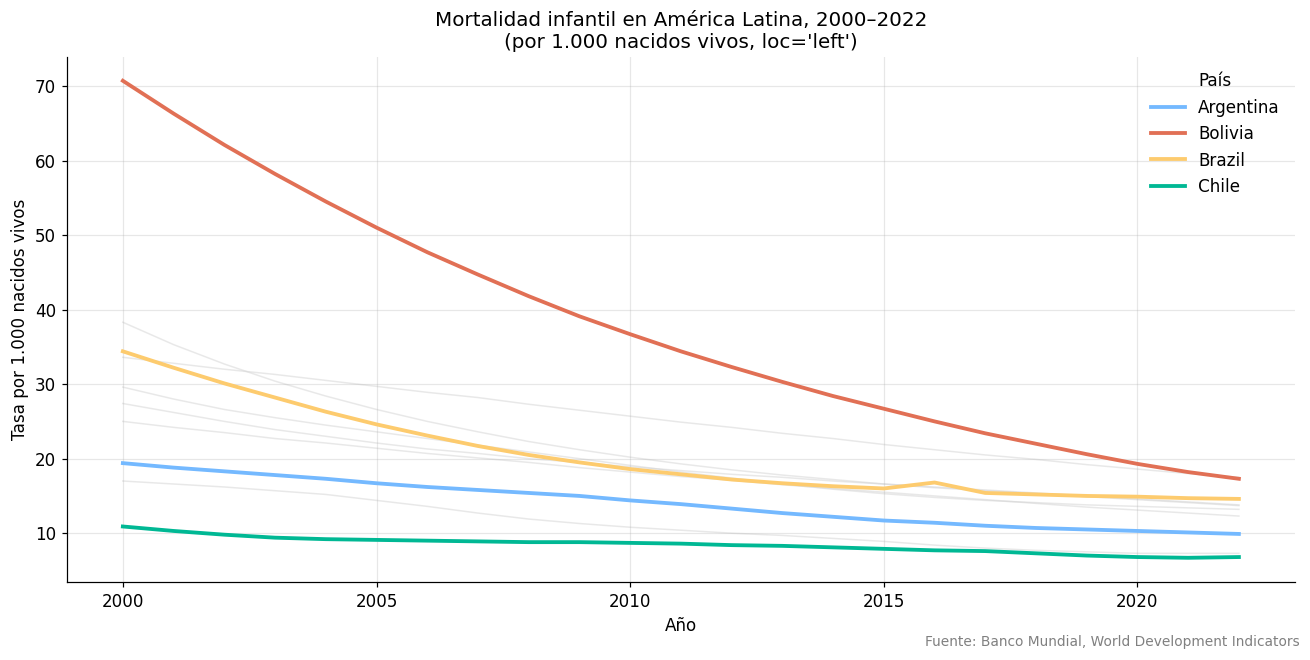

In [7]:
# Visualizar la evolución
if df_mort is not None:
    fig, ax = plt.subplots(figsize=(12, 6))

    paises_destacar = ['Argentina', 'Chile', 'Bolivia', 'Brazil']
    colores = {'Argentina': '#74b9ff', 'Chile': '#00b894', 'Bolivia': '#e17055', 'Brazil': '#fdcb6e'}

    for pais, grupo in df_mort.groupby('pais'):
        serie = grupo.sort_values('anio')
        if pais in paises_destacar:
            ax.plot(serie['anio'], serie['valor'],
                    linewidth=2.5, color=colores[pais], label=pais, zorder=3)
        else:
            ax.plot(serie['anio'], serie['valor'],
                    linewidth=1, color='lightgray', alpha=0.5, zorder=1)

    ax.set_title("Mortalidad infantil en América Latina, 2000–2022\n(por 1.000 nacidos vivos, loc='left')",
                 fontsize=13)
    ax.set_xlabel("Año")
    ax.set_ylabel("Tasa por 1.000 nacidos vivos")
    ax.legend(title='País', frameon=False)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    fig.text(0.99, 0.01, "Fuente: Banco Mundial, World Development Indicators",
             ha='right', fontsize=9, color='gray')
    plt.tight_layout()
    plt.savefig("mortalidad_infantil_latam.png", dpi=150, bbox_inches='tight')
    plt.show()


---
## 5. Estructura del proyecto final: el policy brief con datos

### ¿Qué es un policy brief?

Un policy brief es un documento corto (2–4 páginas) dirigido a tomadores de decisión. Su objetivo es presentar evidencia sobre un problema de política pública y recomendar acciones.

### Estructura recomendada

**1. Título y resumen ejecutivo** (max. 150 palabras)
- ¿Cuál es el problema?
- ¿Qué encontramos?
- ¿Qué recomendamos?

**2. Descripción del problema** (½ página)
- Contexto y relevancia
- Estadísticas descriptivas clave

**3. Análisis de datos** (1–1.5 páginas)
- 2–3 visualizaciones bien elegidas
- Tabla de estadísticas descriptivas
- Si aplica: correlaciones o regresión

**4. Hallazgos principales** (½ página)
- Bullet points con los resultados más importantes
- Comparaciones relevantes (entre regiones, en el tiempo, con otros países)

**5. Recomendaciones** (½ página)
- 2–3 recomendaciones concretas, respaldadas por la evidencia

**6. Fuentes y metodología** (al pie)
- Origen de los datos
- Notebook con el código (adjunto)

### Entregables del proyecto final

1. **Documento policy brief** (PDF, 2–4 páginas)
2. **Jupyter Notebook** con todo el análisis reproducible
3. **Presentación** de 5 minutos al cierre del curso

In [8]:
# Plantilla de notebook para el proyecto final
# Estructura sugerida para tu notebook de proyecto

print("""
=====================================
 PLANTILLA: PROYECTO FINAL
 Python y Políticas Públicas
=====================================

# [Título del policy brief]
# Autor/a: [nombre]
# Fecha: [fecha]

## 0. Configuración
   - Importaciones
   - Parámetros globales (fuente de datos, año, colores)

## 1. Carga y limpieza de datos
   - Fuente primaria de datos
   - Pipeline de limpieza
   - Dataset final listo para analizar

## 2. Análisis exploratorio
   - Estadísticas descriptivas
   - Distribuciones
   - Tendencias temporales (si aplica)

## 3. Análisis principal
   - Correlaciones / comparaciones / regresión
   - Resultados clave

## 4. Visualizaciones para el brief
   - 2-3 gráficos de publicación (alta resolución)
   - Guardar como PNG/SVG

## 5. Conclusiones
   - Hallazgos principales
   - Limitaciones del análisis
""")


 PLANTILLA: PROYECTO FINAL
 Python y Políticas Públicas

# [Título del policy brief]
# Autor/a: [nombre]
# Fecha: [fecha]

## 0. Configuración
   - Importaciones
   - Parámetros globales (fuente de datos, año, colores)

## 1. Carga y limpieza de datos
   - Fuente primaria de datos
   - Pipeline de limpieza
   - Dataset final listo para analizar

## 2. Análisis exploratorio
   - Estadísticas descriptivas
   - Distribuciones
   - Tendencias temporales (si aplica)

## 3. Análisis principal
   - Correlaciones / comparaciones / regresión
   - Resultados clave

## 4. Visualizaciones para el brief
   - 2-3 gráficos de publicación (alta resolución)
   - Guardar como PNG/SVG

## 5. Conclusiones
   - Hallazgos principales
   - Limitaciones del análisis



---
## 6. Checklist de entrega

Antes de entregar el proyecto, verificar:

### Datos y fuentes
- [ ] Los datos provienen de fuentes confiables y están citados
- [ ] El dataset está disponible públicamente o adjunto
- [ ] El período y cobertura geográfica están claramente especificados

### Análisis
- [ ] El notebook corre de principio a fin sin errores (Kernel → Restart & Run All)
- [ ] La limpieza de datos está documentada (pipeline con log)
- [ ] Las estadísticas descriptivas incluyen al menos: media, mediana, desvío, min, max
- [ ] Hay al menos una visualización y una tabla de resultados

### Visualizaciones
- [ ] Todos los gráficos tienen título descriptivo
- [ ] Los ejes están etiquetados con unidades
- [ ] Se indica la fuente de los datos
- [ ] Los gráficos tienen buena resolución (dpi=150 o mayor)

### Policy brief
- [ ] Hay un resumen ejecutivo (≤150 palabras)
- [ ] Los hallazgos están respaldados por los datos
- [ ] Las recomendaciones son concretas y factibles
- [ ] El documento tiene entre 2 y 4 páginas

### Código
- [ ] El código está organizado y es legible
- [ ] Las variables tienen nombres descriptivos
- [ ] No hay código redundante o comentado sin propósito

---
## 7. Ideas de temas para el proyecto final

Si no tenés un tema definido, aquí van algunas ideas con fuentes de datos disponibles:

| Tema | Variable dependiente | Fuentes sugeridas |
|------|---------------------|-------------------|
| Pobreza y educación en Argentina | Tasa de pobreza | INDEC EPH, datos.gob.ar |
| Cobertura de salud por provincia | Mortalidad infantil / cobertura de obra social | DEIS-MSAL, INDEC |
| Desempleo y género | Brecha de empleo por género | INDEC EPH |
| Evolución del gasto social | Ejecución presupuestaria | Ministerio de Economía |
| Acceso a agua potable y saneamiento | % hogares con acceso | Censos INDEC |
| Comparación de indicadores en LATAM | Cualquier indicador | Banco Mundial, CEPAL |
| Matrícula escolar por nivel | Abandono escolar / cobertura | MINEDU, datos.gob.ar |
| Contrataciones y licitaciones públicas | Montos, proveedores | Contrataciones Transparentes |

**Consejo**: elegí un tema que te apasione y para el que encuentres datos fácilmente. Un buen análisis de un tema simple vale más que un análisis confuso de un tema complejo.

In [9]:
# ===== EJEMPLO MÍNIMO COMPLETO =====
# Análisis de mortalidad infantil en América Latina

# El df_mort ya fue cargado (o simulado) más arriba en esta clase

if df_mort is not None:
    print("=" * 55)
    print("RESUMEN EJECUTIVO")
    print("=" * 55)

    ultimo_anio = df_mort['anio'].max()
    ultimos = df_mort[df_mort['anio'] == ultimo_anio]

    print(f"\nAño de análisis: {ultimo_anio}")
    print(f"\nTasas de mortalidad infantil por país ({ultimo_anio}):")
    print(ultimos.sort_values('valor')[['pais', 'valor']].to_string(index=False))

    # Calcular reducción desde 2000
    primer_anio = df_mort['anio'].min()
    primeros = df_mort[df_mort['anio'] == primer_anio][['pais', 'valor']].rename(columns={'valor': 'valor_inicial'})
    resumen = ultimos[['pais', 'valor']].merge(primeros, on='pais')
    resumen['reduccion_pct'] = ((resumen['valor_inicial'] - resumen['valor']) / resumen['valor_inicial'] * 100).round(1)

    print(f"\nReducción promedio desde {primer_anio}: {resumen['reduccion_pct'].mean():.1f}%")
    print(f"Mayor reducción: {resumen.loc[resumen['reduccion_pct'].idxmax(), 'pais']} ({resumen['reduccion_pct'].max():.1f}%)")
    print(f"Menor reducción: {resumen.loc[resumen['reduccion_pct'].idxmin(), 'pais']} ({resumen['reduccion_pct'].min():.1f}%)")

RESUMEN EJECUTIVO

Año de análisis: 2022

Tasas de mortalidad infantil por país (2022):
     pais  valor
    Chile    6.8
  Uruguay    7.3
Argentina    9.9
 Colombia   12.3
  Ecuador   13.2
     Peru   13.7
   Mexico   13.8
   Brazil   14.6
  Bolivia   17.3
 Paraguay   17.5

Reducción promedio desde 2000: 54.5%
Mayor reducción: Bolivia (75.5%)
Menor reducción: Chile (37.6%)
